In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('Student_Performance.csv')
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [4]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [5]:
df.describe() 

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [6]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [7]:
df = pd.get_dummies(df, drop_first=True) 

In [8]:
X = df.drop('Performance Index', axis=1)
y = df['Performance Index']

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [12]:
def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R² Score:", r2_score(y_test, y_pred))

In [13]:
# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
evaluate_model(lr, "Linear Regression")


Linear Regression
MAE: 1.6111213463123042
MSE: 4.082628398521853
R² Score: 0.9889832909573145


In [14]:
# 2. Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_scaled)
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y, test_size=0.2, random_state=42)

In [15]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_poly)
y_pred_poly = poly_model.predict(X_test_poly)

In [16]:
print("\nPolynomial Regression (Degree 2)")
print("MAE:", mean_absolute_error(y_test_poly, y_pred_poly))
print("MSE:", mean_squared_error(y_test_poly, y_pred_poly))
print("R² Score:", r2_score(y_test_poly, y_pred_poly))


Polynomial Regression (Degree 2)
MAE: 1.611522943831509
MSE: 4.0806431061516575
R² Score: 0.9889886481405484


In [17]:
# 3. Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
evaluate_model(lasso, "Lasso Regression")


Lasso Regression
MAE: 1.6267297775811775
MSE: 4.175272506302659
R² Score: 0.9887332968162093


In [18]:
# 4. Ridge Regression
ridge = Ridge(alpha=1)
ridge.fit(X_train, y_train)
evaluate_model(ridge, "Ridge Regression")


Ridge Regression
MAE: 1.6112232281155408
MSE: 4.083211367310289
R² Score: 0.9889817178536919


In [19]:
# 5. Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
evaluate_model(dt, "Decision Tree Regressor")


Decision Tree Regressor
MAE: 2.3530833333333336
MSE: 8.897819444444446
R² Score: 0.9759898089257194


In [20]:
# 6. Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
evaluate_model(rf, "Random Forest Regressor")


Random Forest Regressor
MAE: 1.814944462301587
MSE: 5.1710539517772505
R² Score: 0.9860462449015971


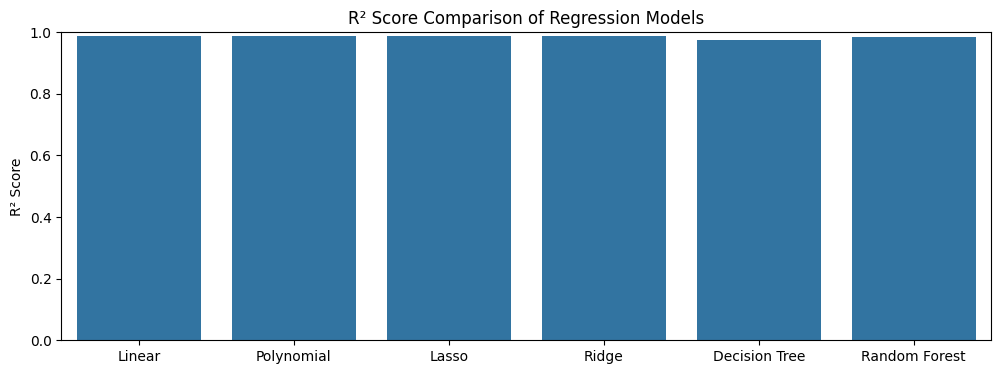

In [22]:
models = ['Linear', 'Polynomial', 'Lasso', 'Ridge', 'Decision Tree', 'Random Forest']
r2_scores = [
    r2_score(y_test, lr.predict(X_test)),
    r2_score(y_test_poly, y_pred_poly),
    r2_score(y_test, lasso.predict(X_test)),
    r2_score(y_test, ridge.predict(X_test)),
    r2_score(y_test, dt.predict(X_test)),
    r2_score(y_test, rf.predict(X_test))
]

plt.figure(figsize=(12, 4))
sns.barplot(x=models, y=r2_scores)
plt.title('R² Score Comparison of Regression Models')
plt.ylabel('R² Score')
plt.ylim(0, 1)
plt.show()